# Experimento 6 - LLM + LoRA (contexto de 3 oraciones)

Fine-tuning de Qwen2.5-1.5B-Instruct con LoRA sobre `multicite_3ctx_balanceado`.
Entrada: `context`. Salida: una de las cinco etiquetas.

`SMOKE=False` para la corrida real (Colab con GPU).

## 0. Entorno (Colab)

Correr una vez. En local no hace nada.

In [1]:
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print("Colab:", IN_COLAB)

Colab: True


In [2]:
if IN_COLAB:
    import os, sys

    if not os.path.exists("/content/citation-recommendation-nlp"):
        !git clone -q https://github.com/jtorresor/citation-recommendation-nlp.git /content/citation-recommendation-nlp
    os.chdir("/content/citation-recommendation-nlp")
    sys.path.insert(0, os.path.abspath("src"))

    !pip install -q "transformers>=5.16" "trl>=1.12" peft accelerate datasets mlflow
    !pip uninstall -q -y torchao

In [3]:
if IN_COLAB:
    import os
    import shutil

    os.makedirs("data", exist_ok=True)
    if not os.path.exists("data/multicite_3ctx_balanceado.csv"):
        from google.colab import files
        uploaded = files.upload()
        for name in uploaded:
            shutil.move(name, f"data/{name}")

    os.environ["MLFLOW_TRACKING_URI"] = "file:///content/mlruns"
    os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"
    print(os.listdir("data"))

['multicite_3ctx_balanceado.csv']


## 1. Configuracion

In [4]:
from intencite.config import (MLFLOW_TRACKING_URI, MLFLOW_EXPERIMENT)

from pathlib import Path
import json
import os
import tempfile

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import torch

from datasets import Dataset
from peft import LoraConfig
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer
from trl import SFTConfig, SFTTrainer

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

cwd = Path.cwd()
if cwd.name == "experiments":
    ROOT = cwd.parent.parent
elif cwd.name == "notebooks":
    ROOT = cwd.parent
else:
    ROOT = cwd

DATA_PATH = ROOT / "data" / "multicite_3ctx_balanceado.csv"

TEXT_COL = "context"
LABEL_COL = "label_proyecto"
SPLIT_COL = "split_proyecto"
GROUP_COL = "pair_id"

LABELS = ["Application", "Background", "Comparison", "Gap", "Improvement"]

SMOKE = False

if SMOKE:
    BASE_MODEL = "Qwen/Qwen2.5-0.5B-Instruct"
    NUM_EPOCHS = 1
    MAX_TRAIN = 48
    MAX_EVAL = 24
else:
    BASE_MODEL = "Qwen/Qwen2.5-1.5B-Instruct"
    NUM_EPOCHS = 3
    MAX_TRAIN = None
    MAX_EVAL = None

MAX_LEN = 512
LEARNING_RATE = 2e-4
BATCH_SIZE = 2
GRAD_ACCUM = 8

LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05
LORA_TARGETS = ["q_proj", "k_proj", "v_proj", "o_proj",
                "gate_proj", "up_proj", "down_proj"]

PROMPT_VERSION = "v1"

USE_MLFLOW = True
RUN_NAME = "llm-lora-3ctx-v1"

MLFLOW_TRACKING_URI = os.environ.get("MLFLOW_TRACKING_URI", MLFLOW_TRACKING_URI)

if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

print("ROOT:", ROOT)
print("DATA_PATH:", DATA_PATH)
print("DEVICE:", DEVICE)
print("BASE_MODEL:", BASE_MODEL)
print("SMOKE:", SMOKE)

ROOT: /content/citation-recommendation-nlp
DATA_PATH: /content/citation-recommendation-nlp/data/multicite_3ctx_balanceado.csv
DEVICE: cuda
BASE_MODEL: Qwen/Qwen2.5-1.5B-Instruct
SMOKE: False


## 2. Carga y validacion del dataset

In [5]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"No encontre {DATA_PATH}. Ejecuta `uv run dvc pull` desde la raiz del repositorio."
    )

df = pd.read_csv(DATA_PATH)

required = {TEXT_COL, LABEL_COL, SPLIT_COL, GROUP_COL}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Faltan columnas obligatorias: {missing}")

model_df = df.dropna(subset=[TEXT_COL, LABEL_COL, SPLIT_COL, GROUP_COL]).copy()
model_df[TEXT_COL] = model_df[TEXT_COL].astype(str)
model_df[LABEL_COL] = model_df[LABEL_COL].astype(str)

unknown = set(model_df[LABEL_COL]) - set(LABELS)
if unknown:
    raise ValueError(f"Etiquetas fuera del esquema de cinco clases: {unknown}")

print("Shape:", model_df.shape)
print("\nSplits:")
print(model_df[SPLIT_COL].value_counts())
print("\nClases:")
print(model_df[LABEL_COL].value_counts())

Shape: (3491, 9)

Splits:
split_proyecto
train    2491
test      517
val       483
Name: count, dtype: int64

Clases:
label_proyecto
Gap            700
Comparison     700
Application    700
Background     700
Improvement    691
Name: count, dtype: int64


## 3. Particiones oficiales y control de leakage

In [6]:
train_df = model_df[model_df[SPLIT_COL] == "train"].copy()
val_df = model_df[model_df[SPLIT_COL] == "val"].copy()
test_df = model_df[model_df[SPLIT_COL] == "test"].copy()

train_pairs = set(train_df[GROUP_COL])
val_pairs = set(val_df[GROUP_COL])
test_pairs = set(test_df[GROUP_COL])

assert train_pairs.isdisjoint(val_pairs)
assert train_pairs.isdisjoint(test_pairs)
assert val_pairs.isdisjoint(test_pairs)

def balanced_head(frame, total):
    per_class = total // len(LABELS)
    parts = [
        g.sample(min(len(g), per_class), random_state=SEED)
        for _, g in frame.groupby(LABEL_COL)
    ]
    return pd.concat(parts).sample(frac=1, random_state=SEED)


if MAX_TRAIN is not None:
    train_df = balanced_head(train_df, MAX_TRAIN)
if MAX_EVAL is not None:
    val_df = balanced_head(val_df, MAX_EVAL)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))
print("OK: cero solapamiento de pair_id entre train, val y test.")

Train: 2491
Val: 483
Test: 517
OK: cero solapamiento de pair_id entre train, val y test.


## 4. Prompts

In [7]:
SYSTEM_PROMPT = (
    "You classify the function of a citation in a scientific paper. "
    "The target reference is wrapped in <cite> </cite>. "
    "Reply with exactly one of these labels and nothing else:\n"
    "Application - the citing work uses an idea, method or tool from the cited work\n"
    "Background - the reference gives context about the domain or the problem\n"
    "Comparison - the citing work points out similarities or differences with the cited work\n"
    "Gap - the reference motivates the work by pointing to an unmet need\n"
    "Improvement - the citing work extends or modifies an idea or method from the cited work"
)


def to_messages(context):
    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": context},
    ]


def build_dataset(frame):
    rows = [
        {
            "prompt": to_messages(row[TEXT_COL]),
            "completion": [{"role": "assistant", "content": row[LABEL_COL]}],
        }
        for _, row in frame.iterrows()
    ]
    return Dataset.from_list(rows)


train_ds = build_dataset(train_df)
eval_ds = build_dataset(val_df)

print(train_ds)
print(json.dumps(train_ds[0], indent=2, ensure_ascii=False))

Dataset({
    features: ['prompt', 'completion'],
    num_rows: 2491
})
{
  "prompt": [
    {
      "role": "system",
      "content": "You classify the function of a citation in a scientific paper. The target reference is wrapped in <cite> </cite>. Reply with exactly one of these labels and nothing else:\nApplication - the citing work uses an idea, method or tool from the cited work\nBackground - the reference gives context about the domain or the problem\nComparison - the citing work points out similarities or differences with the cited work\nGap - the reference motivates the work by pointing to an unmet need\nImprovement - the citing work extends or modifies an idea or method from the cited work"
    },
    {
      "role": "user",
      "content": "The most important challenge in automatic misinformation detection using modern NLP techniques, especially at the level of full news articles, is data. Most previous systems built to identify fake news articles rely on training data label

## 5. Modelo y tokenizador

In [8]:
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
)

print(model.config.model_type, "-", sum(p.numel() for p in model.parameters()) / 1e6, "M parametros")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

qwen2 - 1543.714304 M parametros


## 6. Configuracion de LoRA

In [9]:
lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=LORA_TARGETS,
    bias="none",
    task_type="CAUSAL_LM",
)

## 7. Entrenamiento

In [10]:
sft_config = SFTConfig(
    output_dir=tempfile.mkdtemp(prefix="lora_out_"),
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LEARNING_RATE,
    max_length=MAX_LEN,
    completion_only_loss=True,
    packing=False,
    gradient_checkpointing=(DEVICE == "cuda"),
    fp16=(DEVICE == "cuda"),
    logging_steps=5,
    eval_strategy="epoch",
    report_to="none",
    seed=SEED,
)

trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    processing_class=tokenizer,
    peft_config=lora_config,
)

trainer.model.print_trainable_parameters()
train_result = trainer.train()
print(train_result.metrics)

Tokenizing train dataset:   0%|          | 0/2491 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/2491 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/2491 [00:00<?, ? examples/s]

Dropping fully masked examples from train dataset:   0%|          | 0/2491 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/483 [00:00<?, ? examples/s]

...

Dropping fully masked examples from eval dataset:   0%|          | 0/483 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820


Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
1,0.337412,0.278073,0.292724,606663.000000,0.905988
2,0.243344,0.280202,0.257601,1213326.000000,0.903487
3,0.136885,0.324424,0.166800,1819989.000000,0.900420


{'train_runtime': 2156.81, 'train_samples_per_second': 3.463, 'train_steps_per_second': 0.217, 'total_flos': 1.58723144552448e+16, 'train_loss': 0.26740345970178264, 'epoch': 3.0}


## 8. Prediccion con probabilidades por clase

Se puntua cada etiqueta por el log-prob medio que le asigna el modelo y se normaliza con softmax.

In [11]:
eval_model = trainer.model
eval_model.eval()
if hasattr(eval_model, "config"):
    eval_model.config.use_cache = True


@torch.no_grad()
def predict_with_probs(frame):
    preds = []
    prob_rows = []
    for context in tqdm(frame[TEXT_COL], desc="scoring"):
        messages = to_messages(context)
        prompt_ids = tokenizer.apply_chat_template(
            messages, add_generation_prompt=True, return_tensors="pt", return_dict=False
        )
        p_len = prompt_ids.shape[1]

        scores = []
        for label in LABELS:
            full = messages + [{"role": "assistant", "content": label}]
            full_ids = tokenizer.apply_chat_template(
                full, return_tensors="pt", return_dict=False
            )
            target = full_ids[0, p_len:]
            logits = eval_model(full_ids.to(DEVICE)).logits[0]
            logprobs = torch.log_softmax(logits.float(), dim=-1)
            step = logprobs[p_len - 1: full_ids.shape[1] - 1, :]
            tok_lp = step.gather(1, target.to(DEVICE).unsqueeze(1)).squeeze(1)
            scores.append(tok_lp.mean().item())

        probs = torch.softmax(torch.tensor(scores), dim=-1).tolist()
        preds.append(LABELS[int(np.argmax(scores))])
        prob_rows.append(dict(zip(LABELS, probs)))

    return preds, pd.DataFrame(prob_rows, index=frame.index)

## 9. Evaluacion en validacion

In [12]:
def score(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "f1_micro": f1_score(y_true, y_pred, average="micro"),
    }


val_pred, val_probs = predict_with_probs(val_df)
val_metrics = score(val_df[LABEL_COL], val_pred)
val_report = classification_report(
    val_df[LABEL_COL], val_pred, output_dict=True, zero_division=0
)

print(json.dumps(val_metrics, indent=2))
print()
print(classification_report(val_df[LABEL_COL], val_pred, zero_division=0))

{
  "accuracy": 0.6873706004140787,
  "precision_macro": 0.6887666768213608,
  "recall_macro": 0.6887933423261654,
  "f1_macro": 0.6863467561804921,
  "f1_micro": 0.6873706004140787
}

              precision    recall  f1-score   support

 Application       0.74      0.71      0.72       102
  Background       0.69      0.65      0.67        89
  Comparison       0.73      0.62      0.67       108
         Gap       0.62      0.67      0.64        91
 Improvement       0.67      0.80      0.73        93

    accuracy                           0.69       483
   macro avg       0.69      0.69      0.69       483
weighted avg       0.69      0.69      0.69       483



## 10. Matriz de confusion de validacion

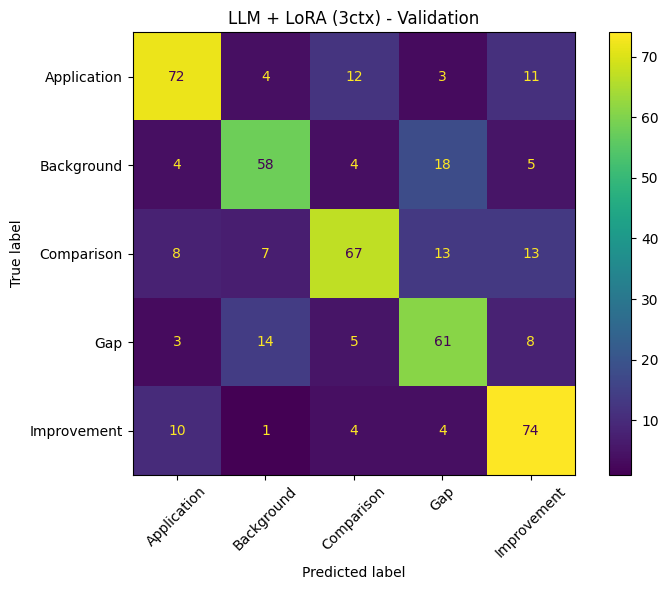

In [13]:
cm = confusion_matrix(val_df[LABEL_COL], val_pred, labels=LABELS)

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS).plot(
    ax=ax, xticks_rotation=45, values_format="d"
)
ax.set_title("LLM + LoRA (3ctx) - Validation")
plt.tight_layout()
plt.show()

## 11. Registro en MLflow

In [16]:
if USE_MLFLOW:
    mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
    mlflow.set_experiment(MLFLOW_EXPERIMENT)

    with mlflow.start_run(run_name=RUN_NAME) as run:
        mlflow.log_params({
            "base_model": BASE_MODEL,
            "method": "LoRA",
            "context": "3ctx",
            "prompt_version": PROMPT_VERSION,
            "decoding": "label-scoring-mean-logprob",
            "lora_r": LORA_R,
            "lora_alpha": LORA_ALPHA,
            "lora_dropout": LORA_DROPOUT,
            "lora_targets": ",".join(LORA_TARGETS),
            "learning_rate": LEARNING_RATE,
            "num_epochs": NUM_EPOCHS,
            "batch_size": BATCH_SIZE,
            "grad_accum": GRAD_ACCUM,
            "max_len": MAX_LEN,
            "seed": SEED,
            "smoke": SMOKE,
            "train_rows": len(train_df),
            "val_rows": len(val_df),
            "test_rows": len(test_df),
        })

        mlflow.log_metrics({f"val_{k}": float(v) for k, v in val_metrics.items()})

        mlflow.set_tags({
            "project": "IntenCite",
            "stage": "experiment",
            "model_family": "llm_lora",
            "dataset": "multicite_3ctx_proyecto",
        })

        with tempfile.TemporaryDirectory() as tmp:
            tmp = Path(tmp)

            (tmp / "system_prompt.txt").write_text(SYSTEM_PROMPT, encoding="utf-8")
            (tmp / "labels.json").write_text(json.dumps(LABELS), encoding="utf-8")
            (tmp / "classification_report_validation.json").write_text(
                json.dumps(val_report, indent=2), encoding="utf-8"
            )

            cm_path = tmp / "confusion_matrix_validation.png"
            fig, ax = plt.subplots(figsize=(8, 6))
            ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS).plot(
                ax=ax, xticks_rotation=45, values_format="d"
            )
            ax.set_title("LLM + LoRA (3ctx) - Validation")
            plt.tight_layout()
            fig.savefig(cm_path, dpi=160, bbox_inches="tight")
            plt.close(fig)

            pred_out = val_df[[TEXT_COL, LABEL_COL]].copy()
            pred_out["prediction"] = val_pred
            pred_out = pd.concat([pred_out, val_probs.add_prefix("prob_")], axis=1)
            pred_out.to_csv(tmp / "predictions_validation.csv", index=False)

            for name in [
                "system_prompt.txt",
                "labels.json",
                "classification_report_validation.json",
                "confusion_matrix_validation.png",
                "predictions_validation.csv",
            ]:
                mlflow.log_artifact(str(tmp / name), artifact_path="evaluation")

            adapter_dir = tmp / "lora_adapter"
            trainer.model.save_pretrained(str(adapter_dir))
            mlflow.log_artifacts(str(adapter_dir), artifact_path="lora_adapter")

        print("MLflow run ID:", run.info.run_id)
        print("Experiment:", MLFLOW_EXPERIMENT)
        print("Run:", RUN_NAME)
else:
    print("USE_MLFLOW=False: no se registro ninguna corrida.")

2026/09/05 18:31:29 INFO mlflow.tracking.fluent: Experiment with name 'intencite-model-comparison' does not exist. Creating a new experiment.


MLflow run ID: ae6eee3a31e84be1889440384d8353a2
Experiment: intencite-model-comparison
Run: llm-lora-3ctx-v1


## 12. Funcion de inferencia

In [17]:
def predict_citation_function(text: str) -> dict:
    frame = pd.DataFrame({TEXT_COL: [text]})
    pred, probs = predict_with_probs(frame)
    return {
        "prediction": pred[0],
        "probabilities": {k: float(v) for k, v in probs.iloc[0].items()},
    }


example_text = (
    "Previous work <cite> introduced a similar method for citation intent classification, "
    "which we use as the basis of our experimental setup."
)
predict_citation_function(example_text)

{'prediction': 'Application',
 'probabilities': {'Application': 0.2912653088569641,
  'Background': 0.10224363952875137,
  'Comparison': 0.17211994528770447,
  'Gap': 0.1559027135372162,
  'Improvement': 0.27846840023994446}}

## 13. Test final

`RUN_FINAL_TEST=True` solo para la evaluacion final.

In [18]:
RUN_FINAL_TEST = False

if RUN_FINAL_TEST:
    test_pred, _ = predict_with_probs(test_df)
    test_metrics = score(test_df[LABEL_COL], test_pred)
    print(json.dumps(test_metrics, indent=2))
    print()
    print(classification_report(test_df[LABEL_COL], test_pred, zero_division=0))
else:
    print("Test reservado. Cambia RUN_FINAL_TEST=True unicamente para la evaluacion final.")

Test reservado. Cambia RUN_FINAL_TEST=True unicamente para la evaluacion final.
